<a href="https://colab.research.google.com/github/goldspruce/EEG_primer/blob/main/6th_copy_of_EEG_course.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import data**

In [ ]:
!pip install mne

In [ ]:
import mne

This section meant to be used for 3D visualization but it does not work.

In [ ]:
!pip install pyvista
!pip uninstall vtk -y
!pip install --extra-index-url https://wheels.vtk.org vtk==9.3.0
!pip install --extra-index-url https://wheels.vtk.org vtk-osmesa

Found existing installation: vtk 9.3.0
Uninstalling vtk-9.3.0:
  Successfully uninstalled vtk-9.3.0
Looking in indexes: https://pypi.org/simple, https://wheels.vtk.org
  Using cached https://gitlab.kitware.com/api/v4/projects/13/packages/pypi/files/3a02bf6067cae7abfd7f6b1330c69555b715be8ec71a3c8d6471af45a96e8e56/vtk-9.3.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (92.0 MB)
Looking in indexes: https://pypi.org/simple, https://wheels.vtk.org


In [ ]:
#%matplotlib widget
#mne.viz.set_3d_backend('notebook')  # Requires PyVista>=0.38.1

# Set path

In [ ]:
import os
import os.path as op

In [ ]:
# this is optional. It depends on where you save the files
#from google.colab import drive
#drive.mount('/gdrive')
#%cd /gdrive

In [ ]:
data_path = 'MyDrive/Class/EEG/colab_example/example_data'
data_path = 'sample_data'
print(data_path)

sample_data


In [ ]:
raw_fname = op.join(data_path, 'sub-0030.vhdr')
print(raw_fname)

sample_data/sub-0030.vhdr


# import file

In [ ]:
raw = mne.io.read_raw_brainvision(raw_fname, eog=('LEOG', 'REOG', 'EMG1','EMG2'), misc='auto', scale=1.0, preload=True, verbose=None)

Extracting parameters from sample_data/sub-0030.vhdr...
Setting channel info structure...
Reading 0 ... 1140117  =      0.000 ...  1140.117 secs...


<ipython-input-11-aadb897d2a48>:1: RuntimeWarning: Not setting positions of 4 eog channels found in montage:
['LEOG', 'REOG', 'EMG1', 'EMG2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(raw_fname, eog=('LEOG', 'REOG', 'EMG1','EMG2'), misc='auto', scale=1.0, preload=True, verbose=None)
<ipython-input-11-aadb897d2a48>:1: RuntimeWarning: Omitted 240 annotation(s) that were outside data range.
  raw = mne.io.read_raw_brainvision(raw_fname, eog=('LEOG', 'REOG', 'EMG1','EMG2'), misc='auto', scale=1.0, preload=True, verbose=None)


In [ ]:
raw.info
raw.info.ch_names

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'LEOG',
 'REOG',
 'P7',
 'P8',
 'Fz',
 'Cz',
 'Pz',
 'Oz',
 'FC1',
 'FC2',
 'CP1',
 'CP2',
 'FC5',
 'FC6',
 'CP5',
 'CP6',
 'A1',
 'A2',
 'POz',
 'F1',
 'F2',
 'C1',
 'C2',
 'P1',
 'P2',
 'AF3',
 'AF4',
 'FC3',
 'FC4',
 'CP3',
 'CP4',
 'PO3',
 'PO4',
 'F5',
 'F6',
 'C5',
 'C6',
 'P5',
 'P6',
 'AF7',
 'AF8',
 'FT7',
 'FT8',
 'TP7',
 'TP8',
 'PO7',
 'PO8',
 'Fpz',
 'CPz',
 'EMG1',
 'EMG2']

Using matplotlib as 2D backend.


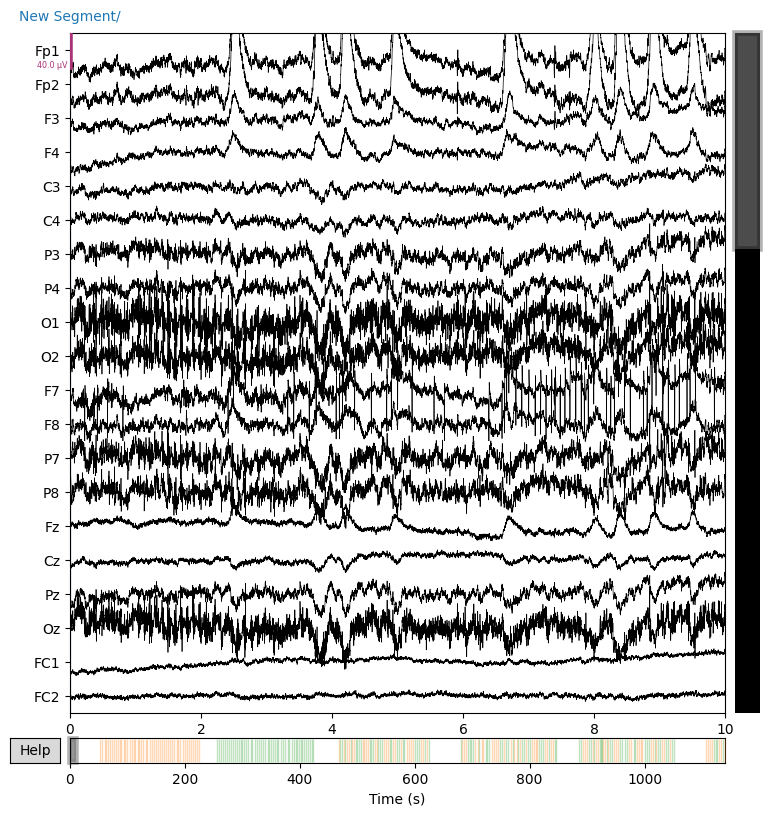

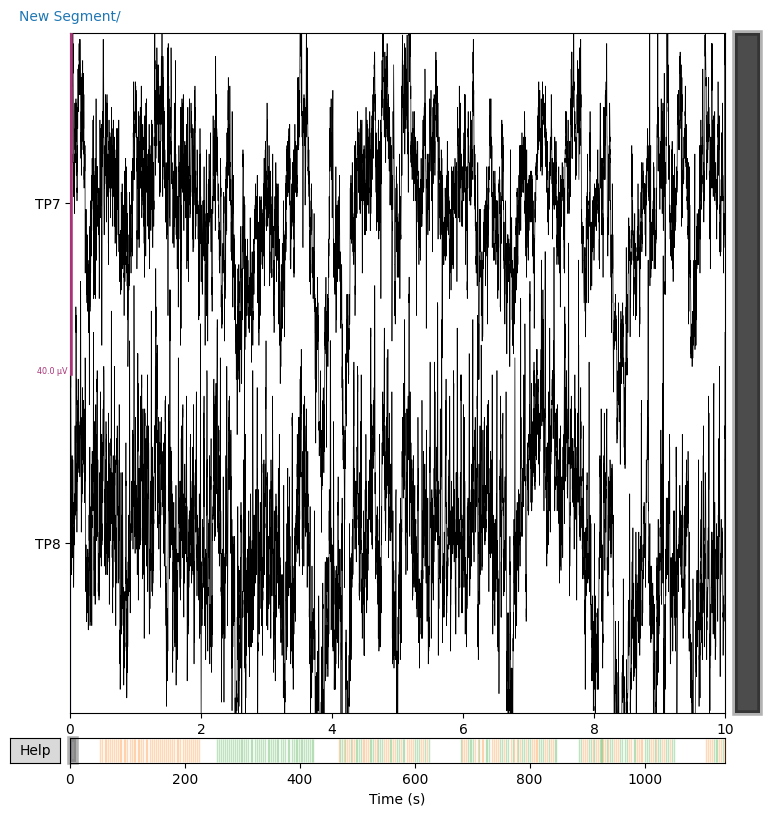

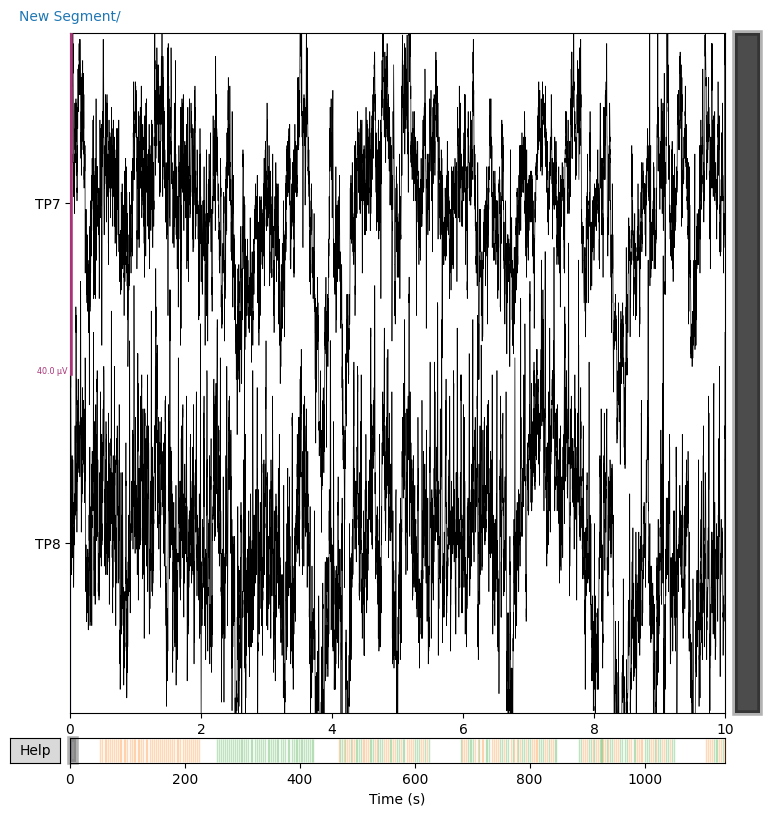

In [ ]:
raw.plot()
picks = mne.pick_channels_regexp(raw.ch_names, regexp='T.')
raw.plot(order=picks, n_channels=len(picks))

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


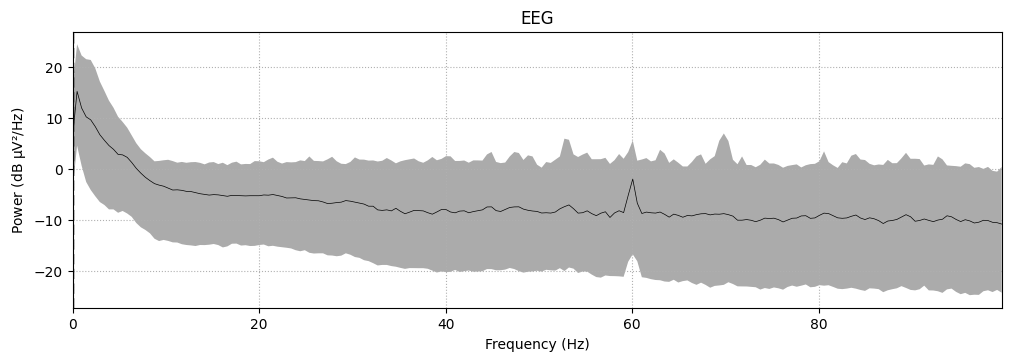

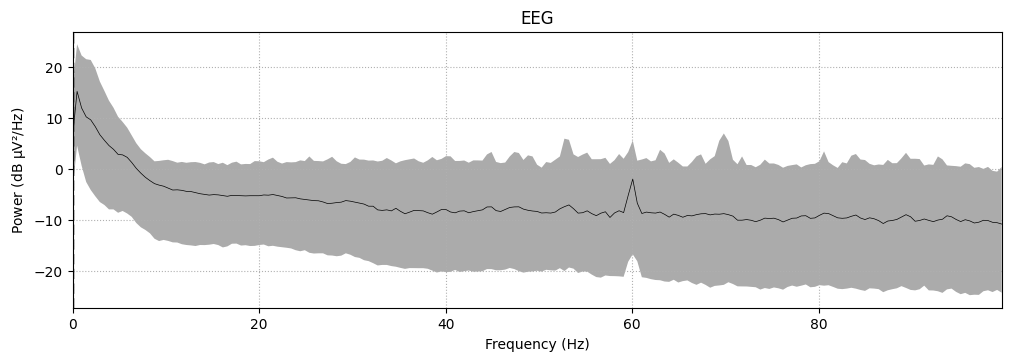

In [ ]:
raw.plot_psd(area_mode='range', fmax=100, show=False, average=True)

# **Filter**

### *https://mne.tools/stable/generated/mne.filter.filter_data.html*

In [ ]:
raw_filtered = raw.copy().filter(l_freq=0.1, h_freq=30) ##need preloaded

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.3s


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


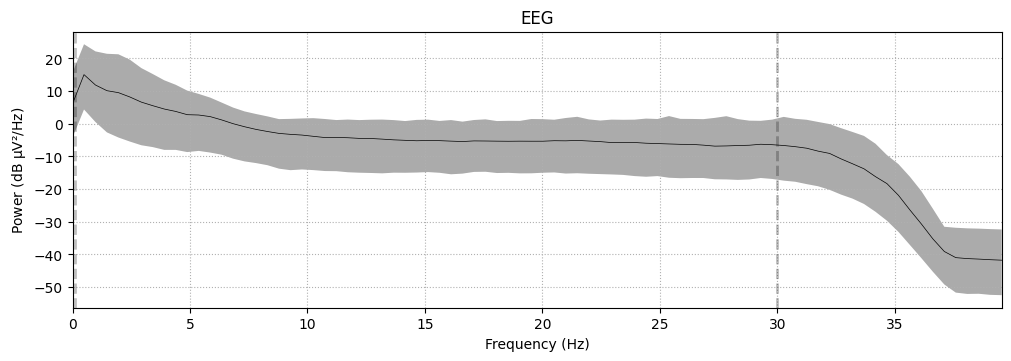

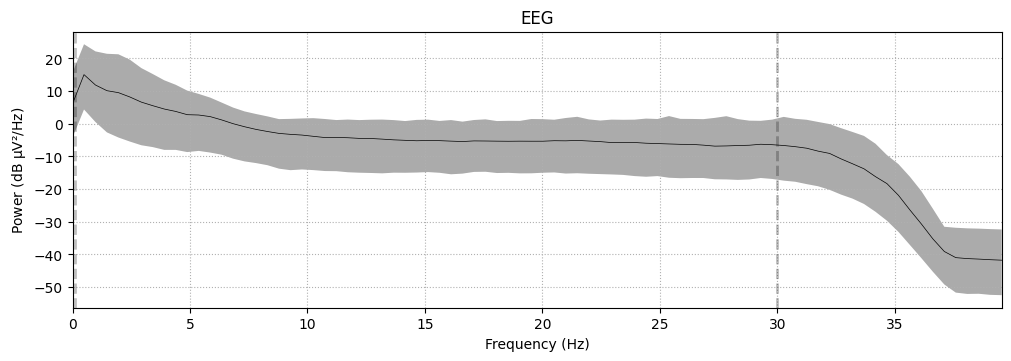

In [ ]:
raw_filtered.plot_psd(area_mode='range', fmax=40, show=False, average=True)

# **Interpolate bad channels**

In [ ]:
raw_filtered.info['bads']=[] # reset bad channels = none
raw_filtered.info['bads'].extend(['TP7','TP8'])
print(raw_filtered.info["bads"])
eeg_interp = raw_filtered.copy().interpolate_bads(reset_bads=False)

['TP7', 'TP8']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 57 sensor positions
Interpolating 2 sensors


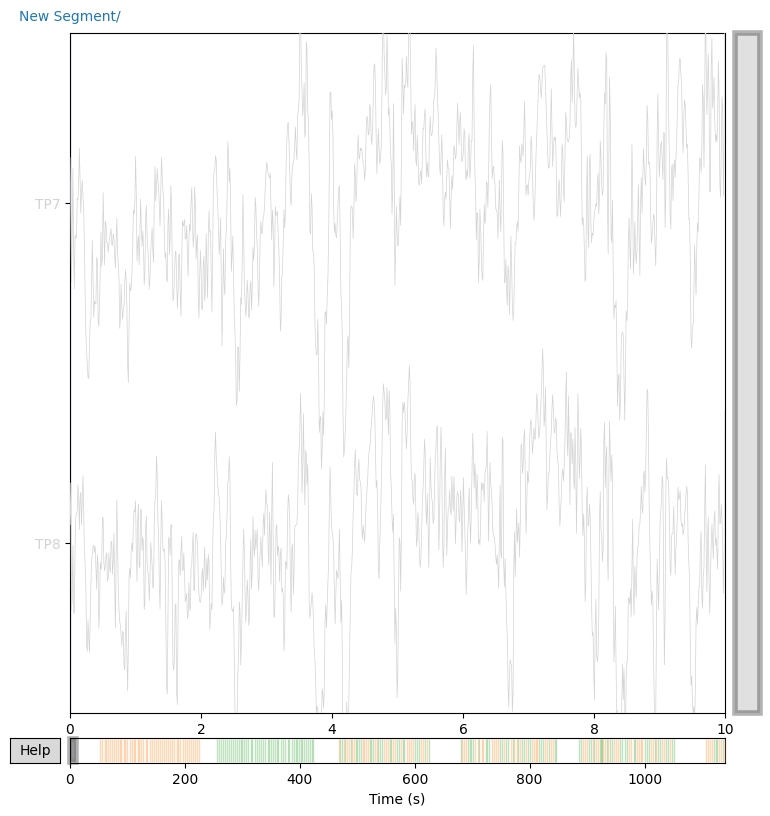

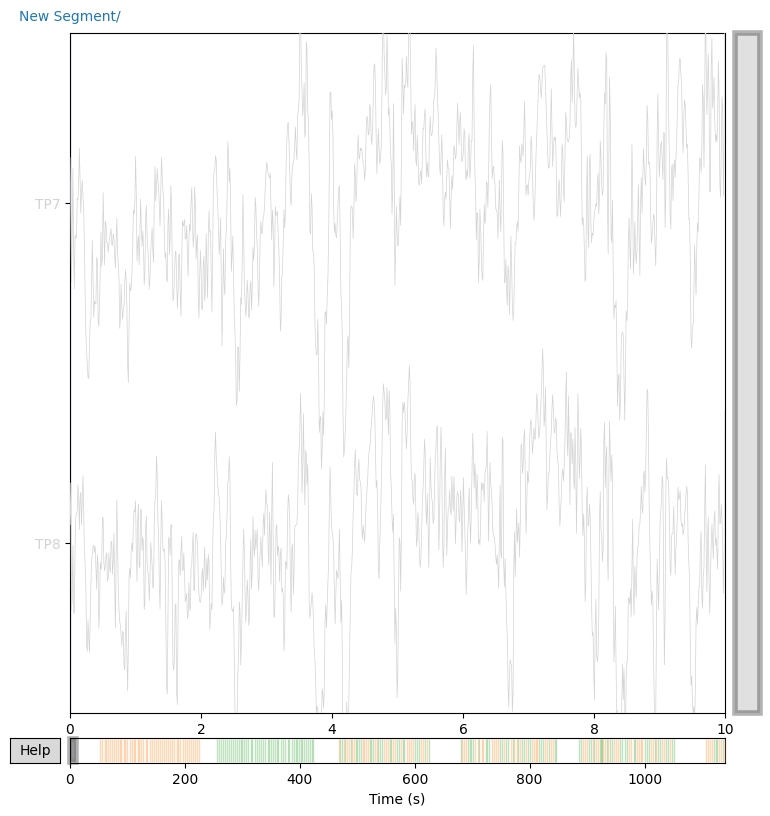

In [ ]:
picks = mne.pick_channels_regexp(eeg_interp.ch_names, regexp='T.')
eeg_interp.plot(order=picks, n_channels=len(picks))

# **ICA**

https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html

In [ ]:
raw_bip_ref = mne.set_bipolar_reference(eeg_interp, anode=["LEOG"], cathode=["REOG"])
raw_bip_ref = mne.set_bipolar_reference(raw_bip_ref, anode=["EMG1"], cathode=["EMG2"])
raw_bip_ref.rename_channels({"LEOG-REOG": "HEOG", "EMG1-EMG2": "VEOG"})
raw_bip_ref.set_channel_types({"VEOG":'eog', "HEOG":'eog'})

EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1140118
    Range : 0 ... 1140117 =      0.000 ...  1140.117 secs
Ready.
Added the following bipolar channels:
LEOG-REOG
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=1140118
    Range : 0 ... 1140117 =      0.000 ...  1140.117 secs
Ready.
Added the following bipolar channels:
EMG1-EMG2


<RawBrainVision | sub-0030.eeg, 61 x 1140118 (1140.1 s), ~530.7 MiB, data loaded>

In [ ]:
### ICA ###
ica = mne.preprocessing.ICA(n_components=15, max_iter="auto", random_state=97)
ica.fit(raw_bip_ref)

Fitting ICA to data using 57 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 109.2s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,48 iterations on raw data (1140118 samples)
ICA components,15
Available PCA components,57
Channel types,eeg
ICA components marked for exclusion,—


Creating RawArray with float64 data, n_channels=17, n_times=1140118
    Range : 0 ... 1140117 =      0.000 ...  1140.117 secs
Ready.


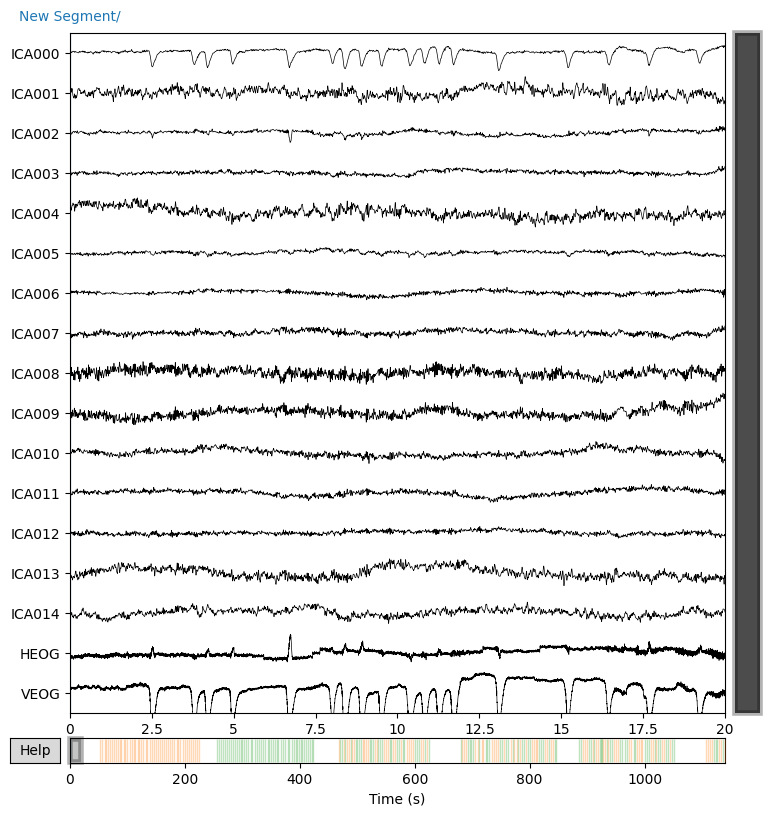

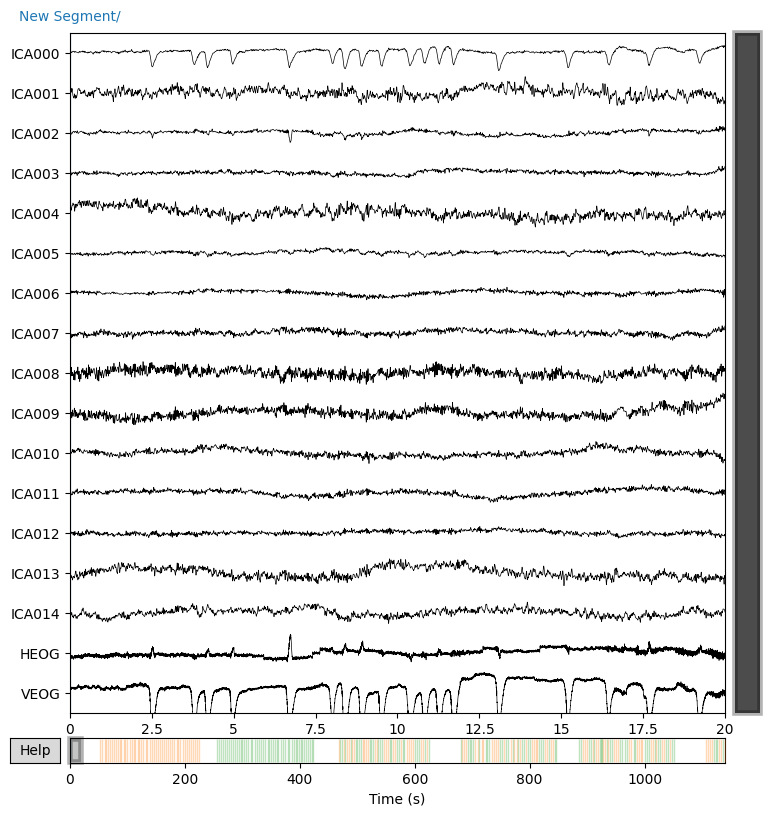

In [ ]:
ica.plot_sources(raw_bip_ref)

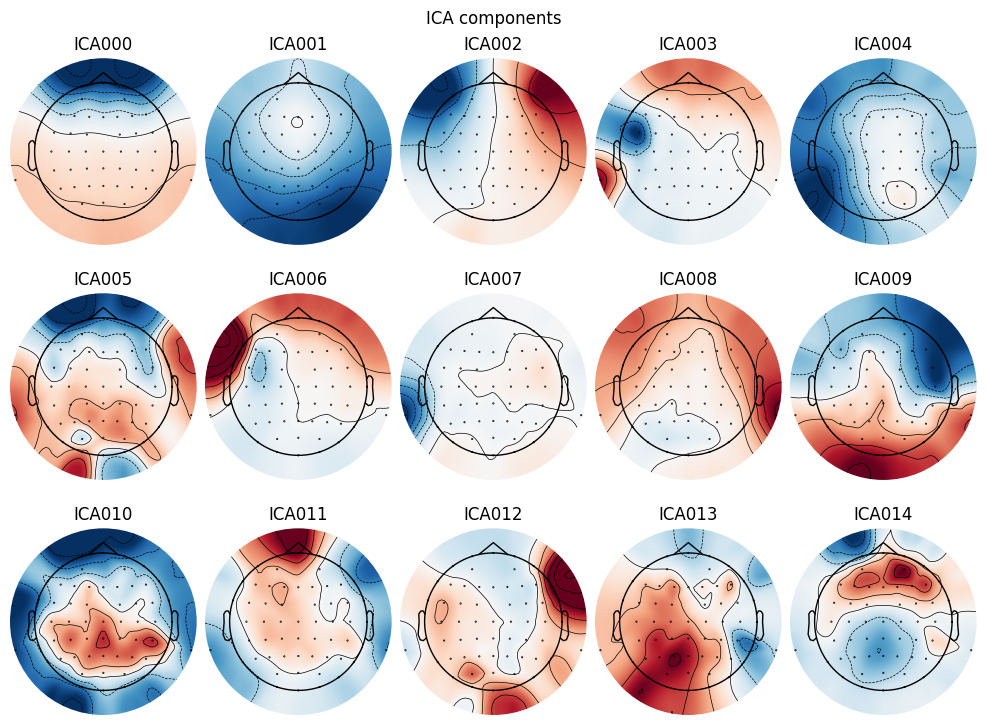

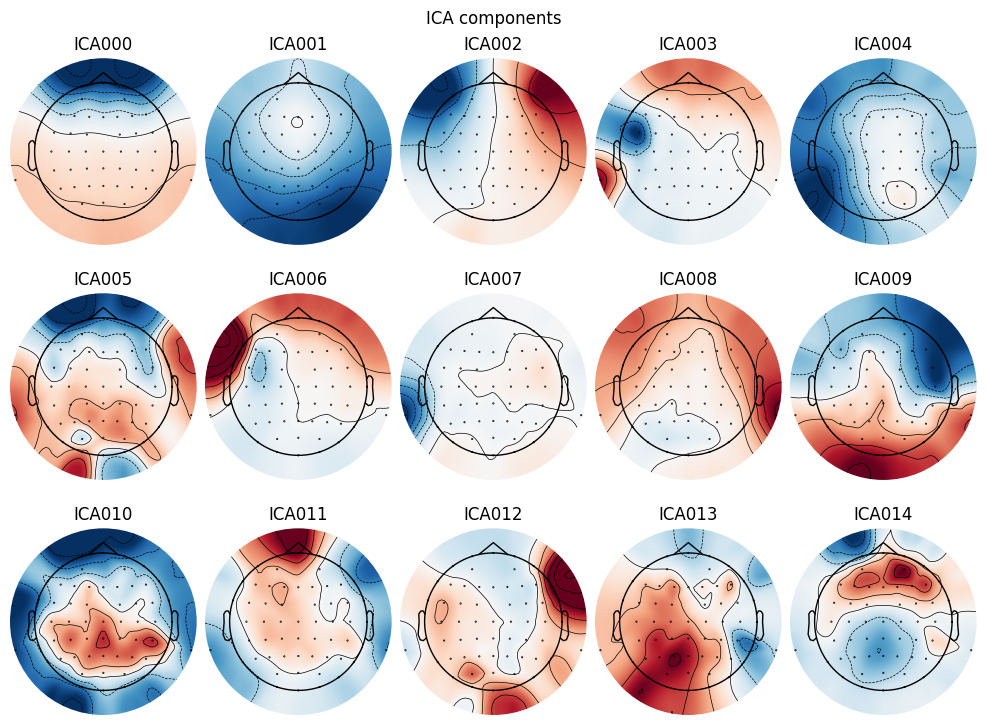

In [ ]:
ica.plot_components()

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
570 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
570 matching events found
No baseline correction applied
0 projection items activated


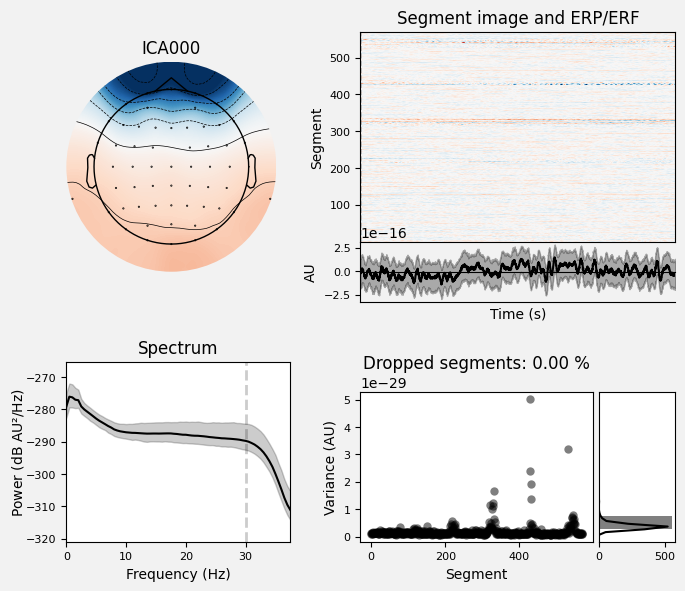

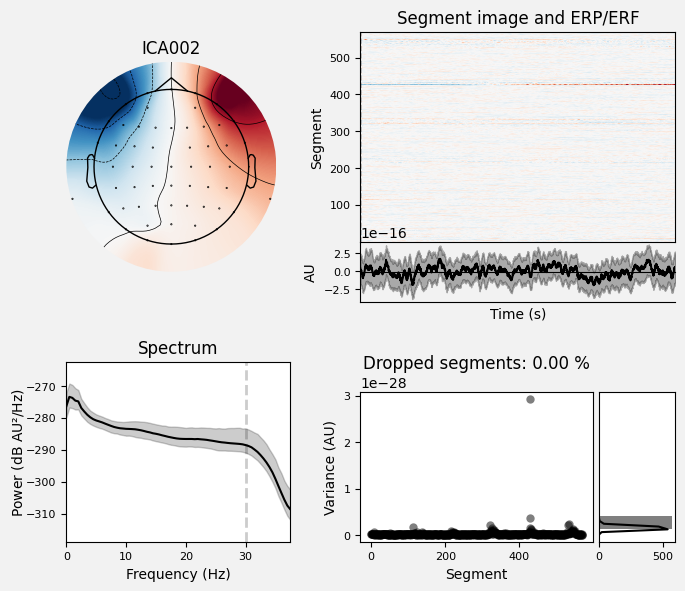

[<Figure size 700x600 with 6 Axes>, <Figure size 700x600 with 6 Axes>]

In [ ]:
ica.plot_properties(raw_bip_ref, picks=[0,2])

In [ ]:
ica.exclude = [0,2]

In [ ]:
ica.apply(raw_bip_ref)

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 57 PCA components


<RawBrainVision | sub-0030.eeg, 61 x 1140118 (1140.1 s), ~530.7 MiB, data loaded>

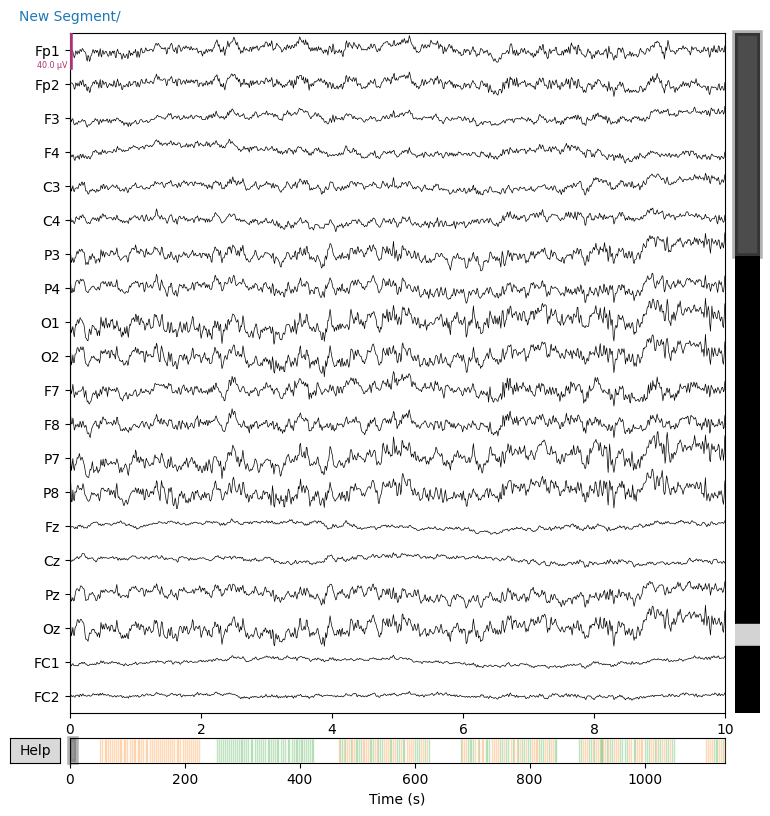

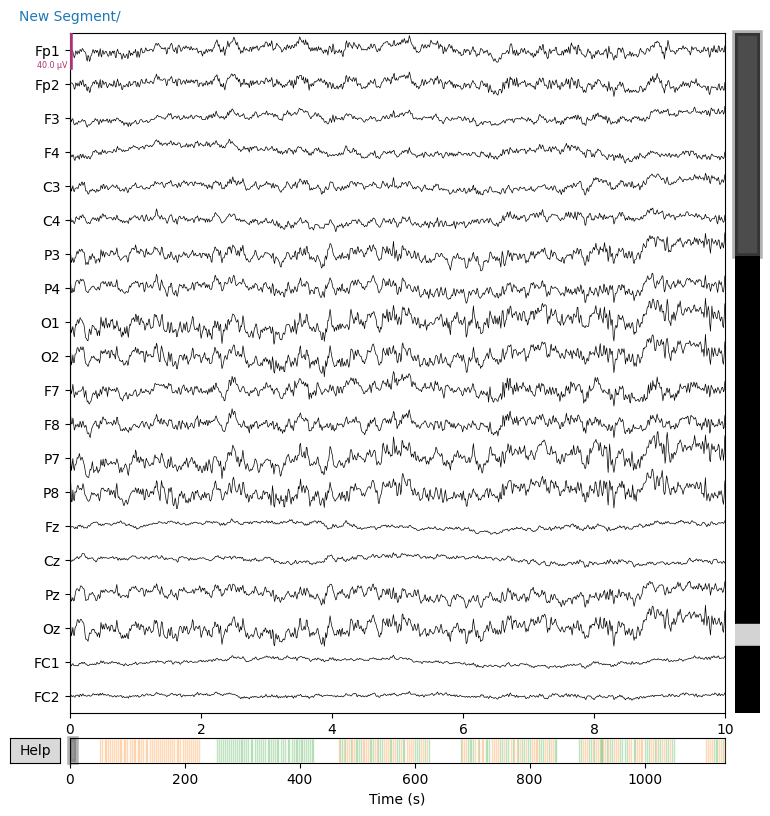

In [ ]:
raw_bip_ref.plot()

In [ ]:
# find which ICs match the EOG pattern
eog_indices, eog_scores = ica.find_bads_eog(raw_bip_ref)
print(eog_indices)
ica.exclude = eog_indices

Using EOG channels: HEOG, VEOG
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.

In [ ]:
ica.apply(raw_bip_ref)

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 57 PCA components


<RawBrainVision | sub-0030.eeg, 61 x 1140118 (1140.1 s), ~530.7 MiB, data loaded>

# re-reference

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


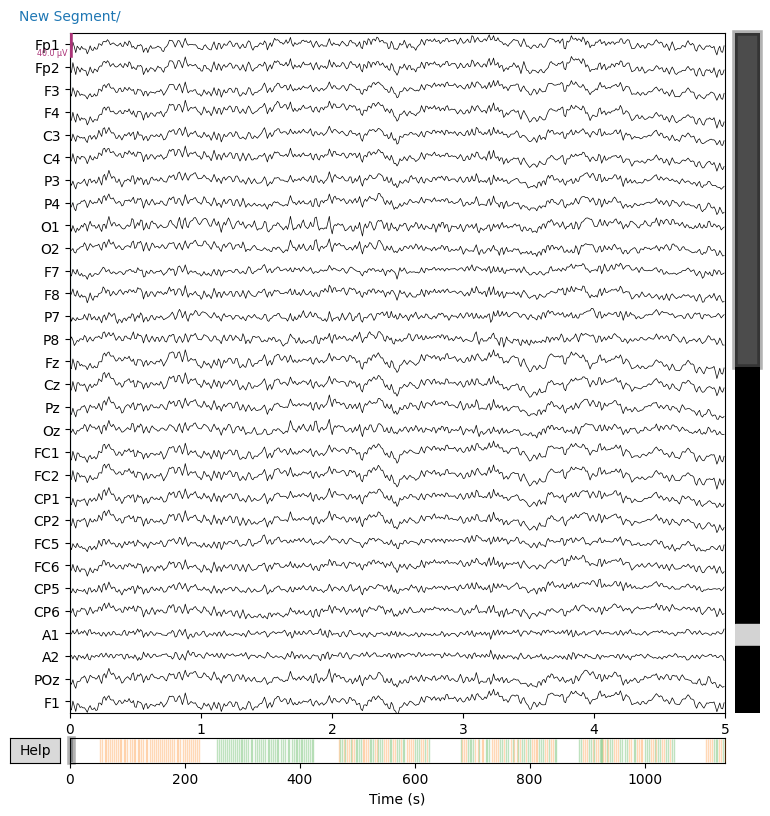

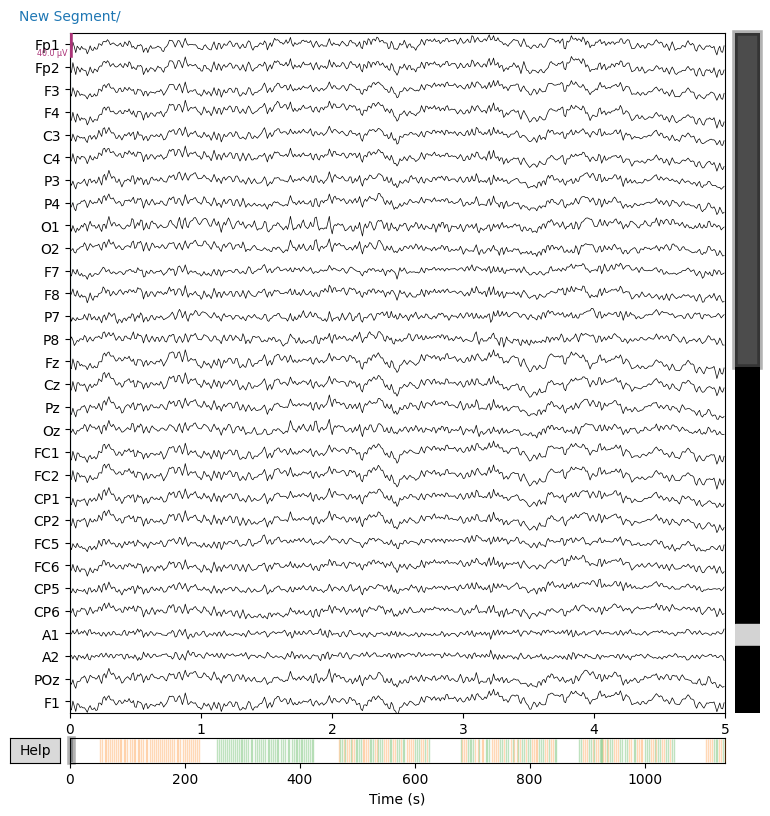

In [ ]:
raw_avg_ref = raw_bip_ref.copy().set_eeg_reference(ref_channels=['A1','A2'])
raw_avg_ref.plot(duration=5, n_channels=30)

# Epoch

In [ ]:
tmin, tmax = -0.2, 1  # in s
baseline = -0.2, 0
events, _ = mne.events_from_annotations(raw_avg_ref, verbose=False)
event_dict = {'Hit': 1,'Miss': 2}

In [ ]:
print(events)

[[      0       0   99999]
 [  52732       0       1]
 [  56219       0       1]
 [  60206       0       1]
 [  63242       0       1]
 [  66713       0       1]
 [  69799       0       1]
 [  73019       0       1]
 [  76355       0       1]
 [  80025       0       1]
 [  83128       0       1]
 [  86298       0       1]
 [  89618       0       1]
 [  93238       0       1]
 [  96208       0       1]
 [ 100028       0       1]
 [ 103648       0       1]
 [ 107235       0       1]
 [ 110755       0       1]
 [ 113692       0       1]
 [ 117529       0       1]
 [ 120882       0       1]
 [ 123885       0       1]
 [ 127271       0       1]
 [ 131442       0       1]
 [ 134645       0       1]
 [ 138432       0       1]
 [ 142503       0       1]
 [ 145523       0       1]
 [ 149310       0       1]
 [ 152730       0       1]
 [ 156784       0       1]
 [ 159937       0       1]
 [ 163707       0       1]
 [ 166910       0       1]
 [ 170147       0       1]
 [ 174217       0       1]
 

In [ ]:
epochs = mne.Epochs(raw_avg_ref.copy(), events=events, tmin=tmin,tmax=tmax, baseline=baseline, event_id=event_dict,
    reject_by_annotation=False, preload=True, verbose=False)

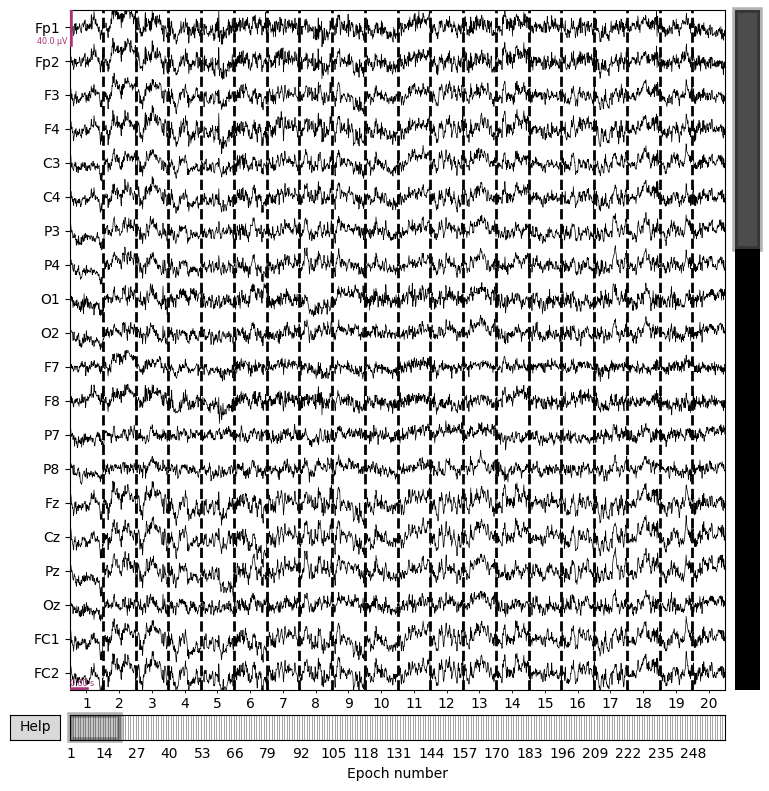

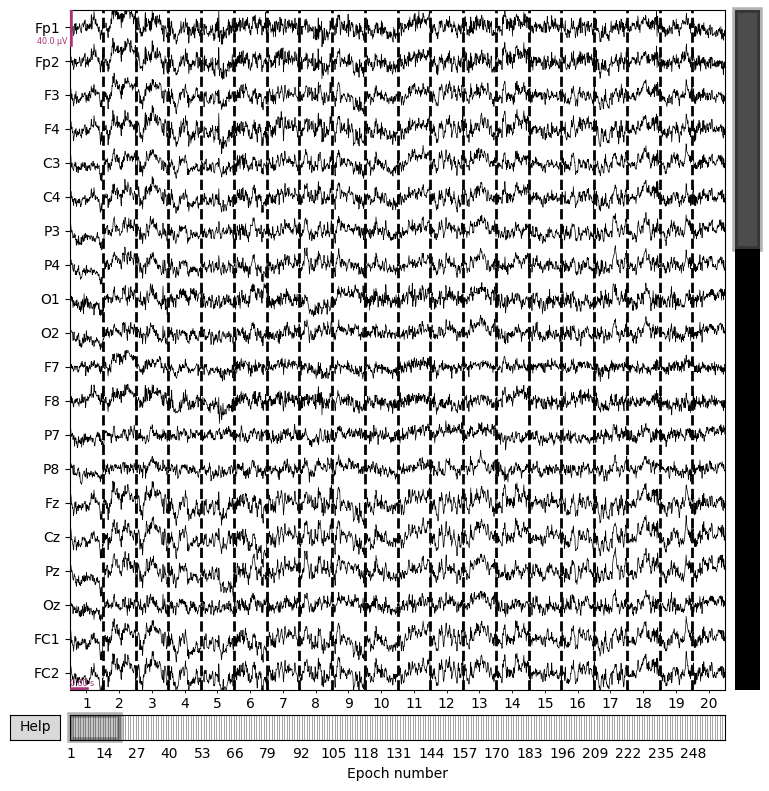

In [ ]:
epochs.plot()

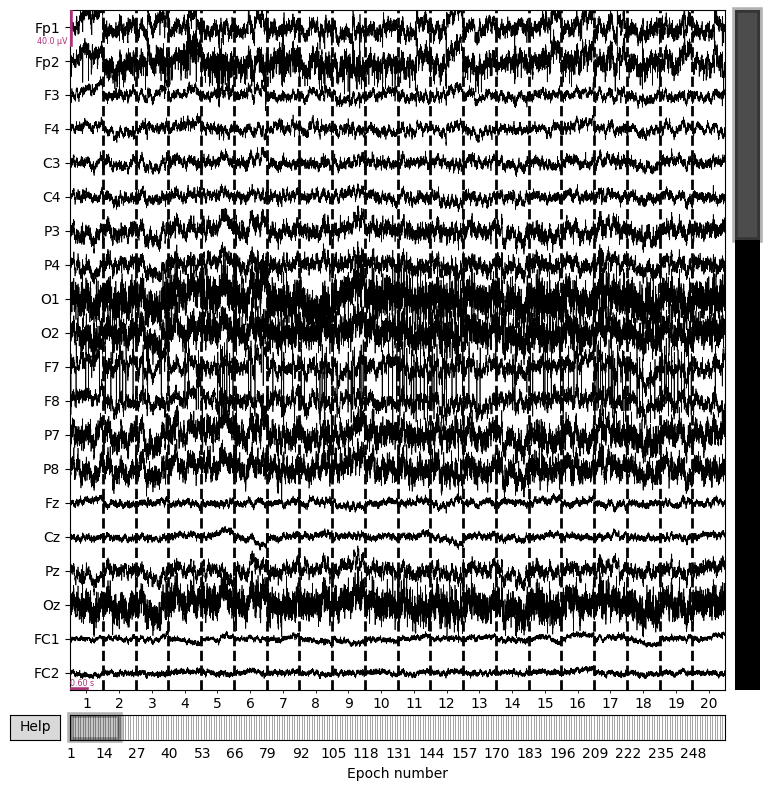

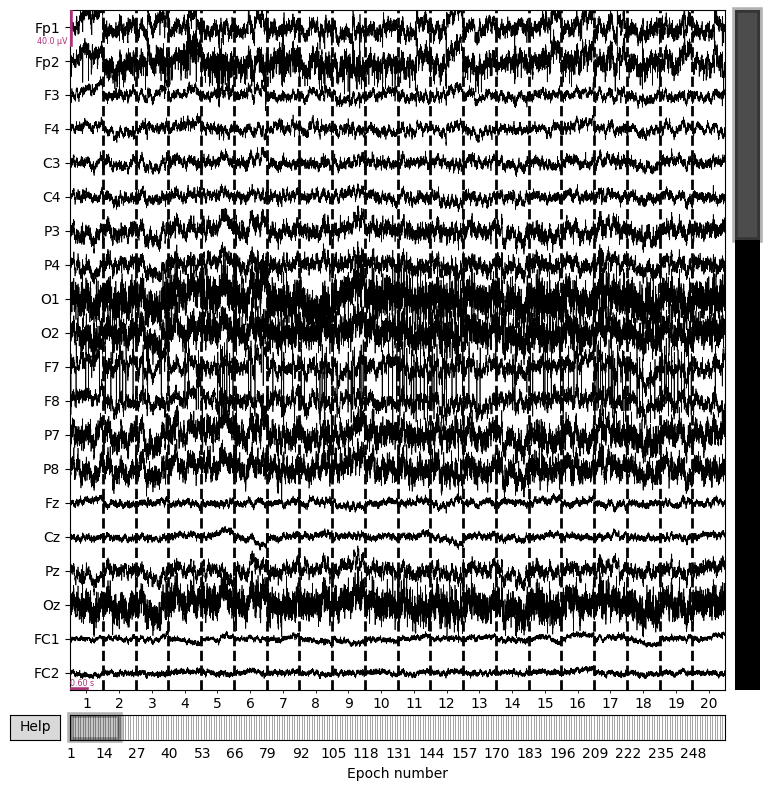

In [ ]:
#March 31 HW - Epoch etc raw data
epochs_HW = mne.Epochs(raw.copy(), events=events, tmin=tmin,tmax=tmax, baseline=baseline, event_id=event_dict,
    reject_by_annotation=False, preload=True, verbose=False)
epochs_HW.plot()

# Artifact rejection

    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EOG : ['VEOG']
    Rejecting  epoch based on EOG : ['VEOG']
    Rejecting  epoch based on EOG : ['VEOG']
    Rejecting  epoch based on EOG : ['VEOG']
5 bad epochs dropped


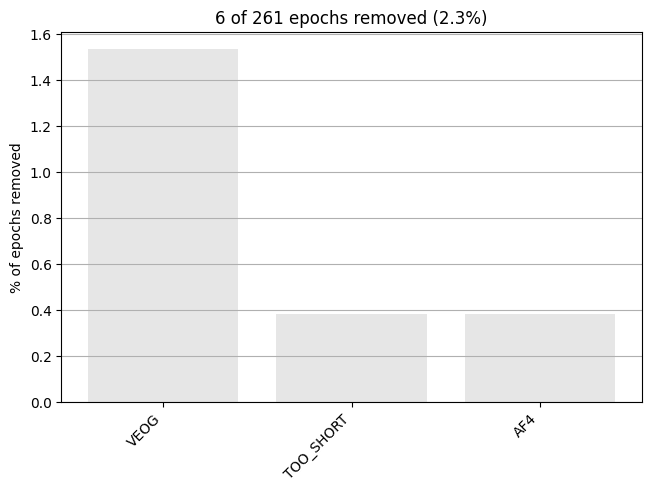

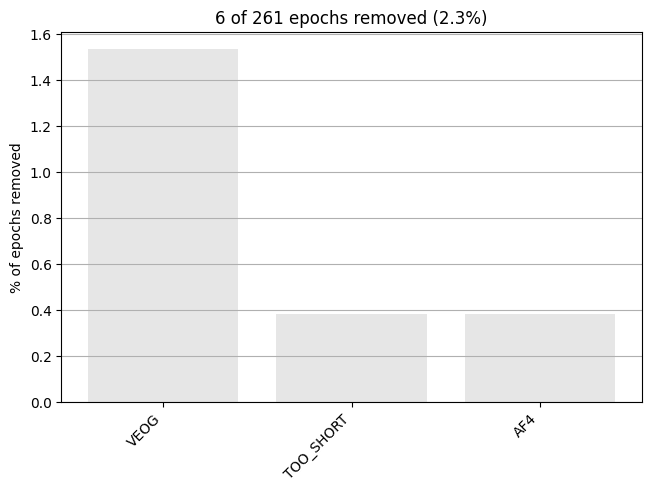

In [ ]:
reject_criteria = dict(eeg=75e-6, eog=200e-6)  # 75 µV, 200 µV
epochs.drop_bad(reject=reject_criteria)
epochs.plot_drop_log()

    Rejecting  epoch based on EEG : ['O1', 'F7']
    Rejecting  epoch based on EEG : ['O2', 'F7', 'AF4']
    Rejecting  epoch based on EEG : ['F7']
    Rejecting  epoch based on EEG : ['O1', 'F7']
    Rejecting  epoch based on EEG : ['Fp2', 'O1', 'F7', 'PO7']
    Rejecting  epoch based on EEG : ['Fp2', 'O1', 'F7', 'A2', 'AF8', 'PO7']
    Rejecting  epoch based on EEG : ['O2', 'F7']
    Rejecting  epoch based on EEG : ['O1', 'F7']
    Rejecting  epoch based on EEG : ['O1', 'O2', 'F7', 'A2', 'PO7']
    Rejecting  epoch based on EEG : ['O1', 'F7', 'PO7']
    Rejecting  epoch based on EEG : ['O1', 'F7']
    Rejecting  epoch based on EEG : ['O1', 'O2', 'F7', 'Oz', 'PO7']
    Rejecting  epoch based on EEG : ['O1', 'F7']
    Rejecting  epoch based on EEG : ['O1', 'A2', 'PO7']
    Rejecting  epoch based on EEG : ['O1', 'F7', 'PO7']
    Rejecting  epoch based on EEG : ['O1', 'F7']
    Rejecting  epoch based on EEG : ['F7']
    Rejecting  epoch based on EEG : ['F7']
    Rejecting  epoch based on

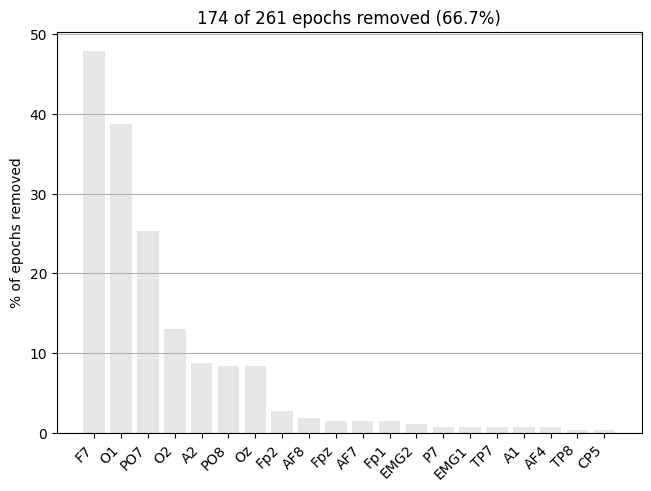

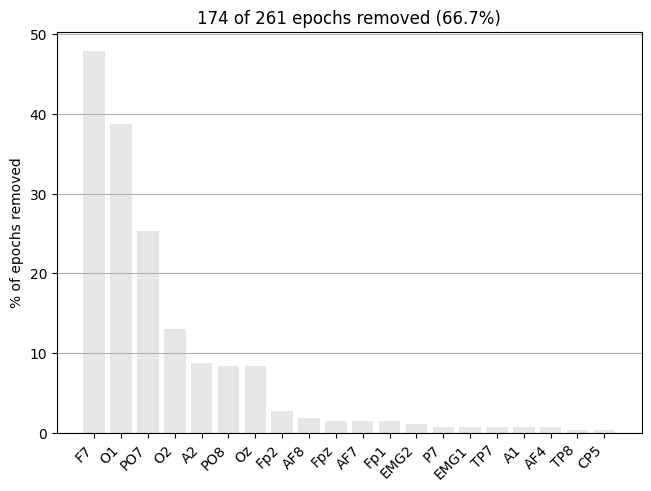

In [ ]:
#March 31 HW - Epoch etc raw data
epochs_HW.drop_bad(reject=reject_criteria)
epochs_HW.plot_drop_log()

In [ ]:
evoked_hit= epochs['Hit'].average()
evoked_miss = epochs['Miss'].average()

In [ ]:
#March 31 HW - Epoch etc raw data
evoked_HW_hit= epochs['Hit'].average()
evoked_HW_miss = epochs['Miss'].average()

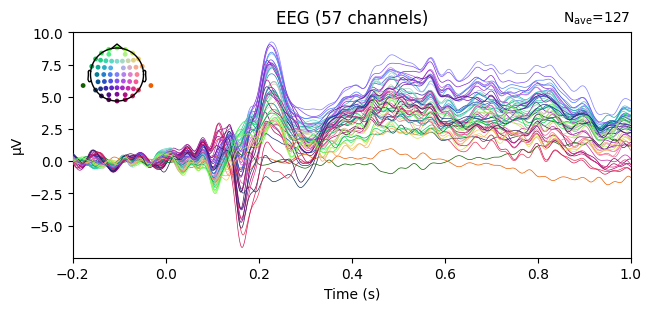

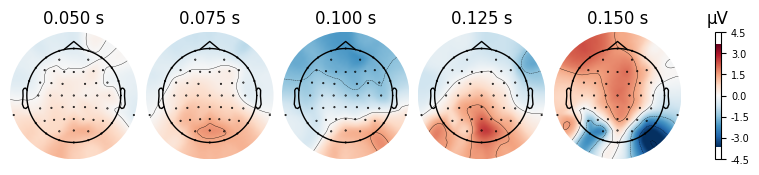

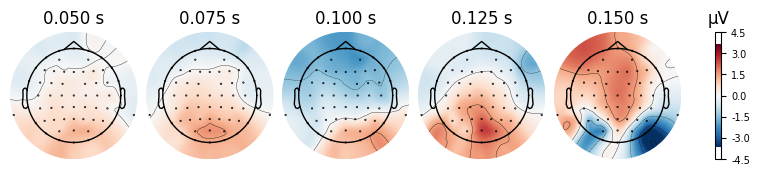

In [ ]:
import numpy as np
evoked_hit.plot(time_unit='s')
evoked_hit.plot_topomap(times=np.linspace(0.05, 0.15, 5),ch_type='eeg',time_unit='s')

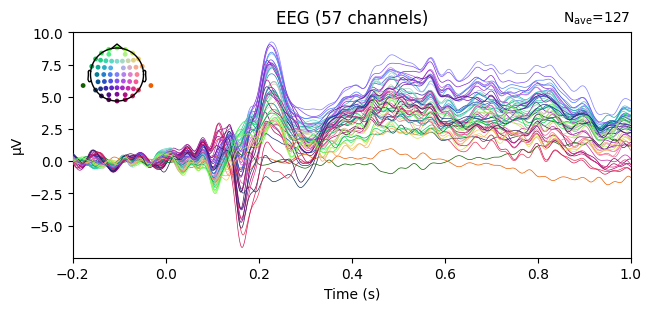

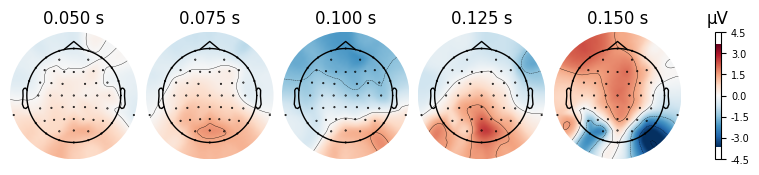

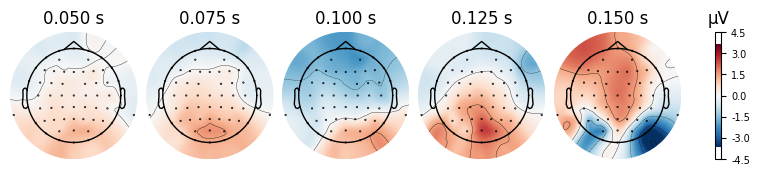

In [ ]:
#March 31 HW - Epoch etc raw data
evoked_HW_hit.plot(time_unit='s')
evoked_HW_hit.plot_topomap(times=np.linspace(0.05, 0.15, 5),ch_type='eeg',time_unit='s')

In [ ]:
evokeds = dict(Hit=list(epochs["Hit"].iter_evoked()), Miss=list(epochs["Miss"].iter_evoked()))
picks = ['Fz']

In [ ]:
#March 31 HW - Epoch etc raw data
evokeds_HW = dict(Hit=list(epochs_HW["Hit"].iter_evoked()), Miss=list(epochs_HW["Miss"].iter_evoked()))
picks_HW = ['Fz']

combining channels using "mean"


<ipython-input-58-bb0a22f6e5fb>:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, combine="mean", picks=picks)


combining channels using "mean"


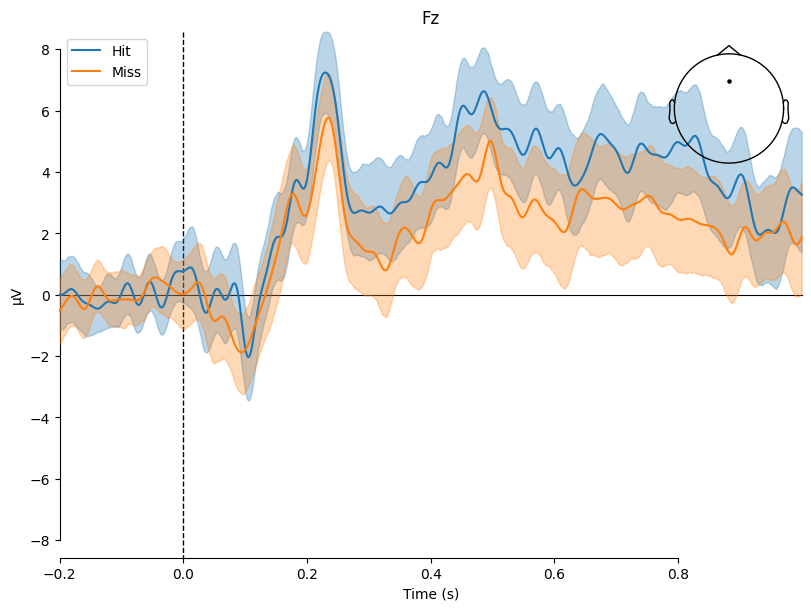

[<Figure size 800x600 with 2 Axes>]

In [ ]:
mne.viz.plot_compare_evokeds(evokeds, combine="mean", picks=picks)

combining channels using "mean"


<ipython-input-69-0e6acbbaab5d>:2: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_HW, combine="mean", picks=picks)


combining channels using "mean"


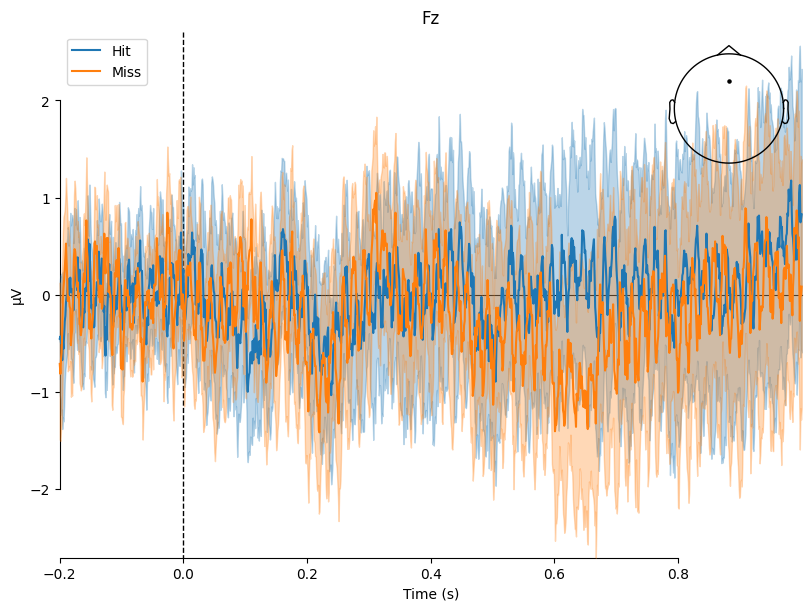

[<Figure size 800x600 with 2 Axes>]

In [ ]:
#March 31 HW - Epoch etc raw data
mne.viz.plot_compare_evokeds(evokeds_HW, combine="mean", picks=picks)

In [ ]:
# if you like to unmount
#from google.colab import drive
#drive.flush_and_unmount()